# Patícula en un potencial Lennard-Jones #

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
#Potencial en funció de x
def getV(x):
    e=100
    s=1
    m=1
    potvalue =4*e*((s/x)**12-(s/x)**6)
    return potvalue

In [23]:
# Discretització de Shrödinger
def Eq(n,h,x):
    F = np.zeros([n,n])
    for i in range(0,n):
        F[i,i] = -2*((h**2)*getV(x[i]) + 1)
        if i > 0:
           F[i,i-1] = 1
           if i < n-1:
              F[i,i+1] = 1
    return F

In [24]:
# Interval de la funció
L = 20
xlower = -L/2.0
xupper = L/2.0

#Discretizació
h = 0.02  

# Crear coordenades
x = np.arange(xlower,xupper+h,h)
# Mesura del grid  
npoints=len(x)

print("Using",npoints, "grid points.")

Using 1001 grid points.


In [35]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)
print (F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Nivells d'energía
E = - w/(2.0*h**2)



[[-10.30420355   0.           0.         ...   0.           0.
    0.        ]
 [  1.         -13.85802453   1.         ...   0.           0.
    0.        ]
 [  0.           1.         -19.00263884 ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...  -1.9998168    1.
    0.        ]
 [  0.           0.           0.         ...   1.          -1.99982301
    1.        ]
 [  0.           0.           0.         ...   0.           1.
   -1.99982897]]


In [26]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=-66.3222
n= 1 , E(numeric)=-66.3222
n= 2 , E(numeric)=-23.0704
n= 3 , E(numeric)=-23.0704
n= 4 , E(numeric)=-4.1819


Plotting


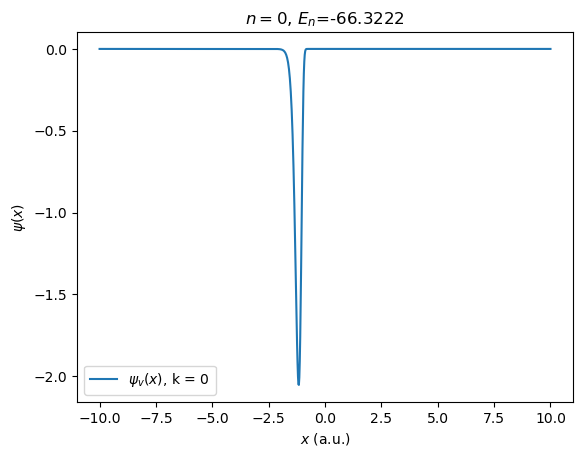

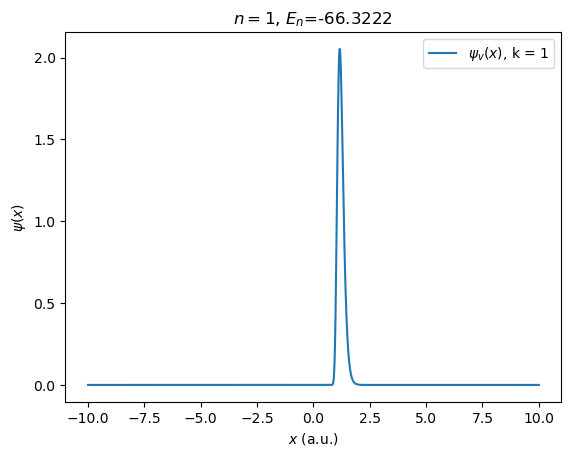

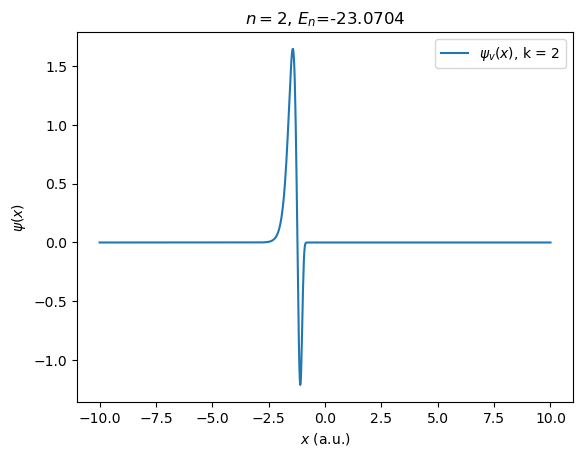

Bye


In [27]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()

print("Bye")


# Càlcul amb modificacions (augmentant h)

En aquest cas el càlcul és més ràpid però es perd qualitat

In [69]:
# Interval for calculating the wave function [-L/2,L/2]
L = 100
xlower = -L*3/400
xupper = L*7/200

#Discretization options
h = 0.2  #discretization in space

#Create coordinates at which the solution will be calculated
x = np.arange(xlower,xupper+h,h)
#grid size (how many discrete points to use in the range [-L/2,L/2])
npoints=len(x)

print("Using",npoints, "grid points.")

Using 23 grid points.


In [70]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Energy Level
E = - w/(2.0*h**2)

In [71]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=-65.8720
n= 1 , E(numeric)=-41.6569
n= 2 , E(numeric)=-17.1514
n= 3 , E(numeric)=-2.6589
n= 4 , E(numeric)=1.0361


Plotting


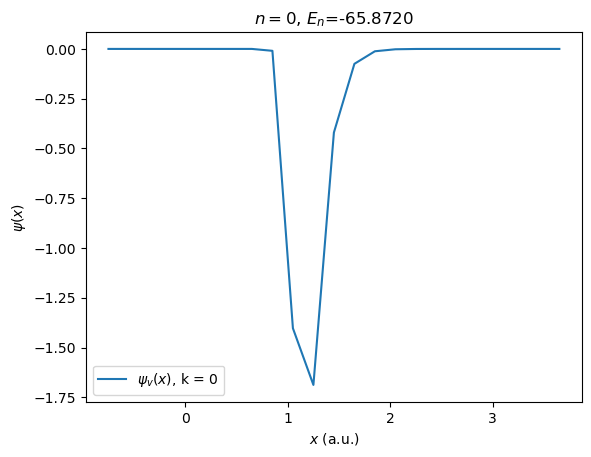

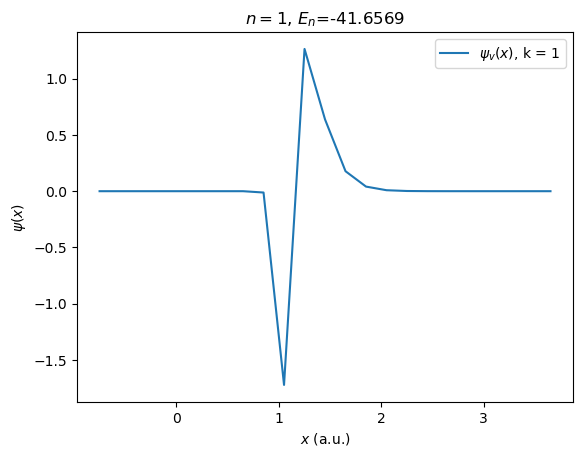

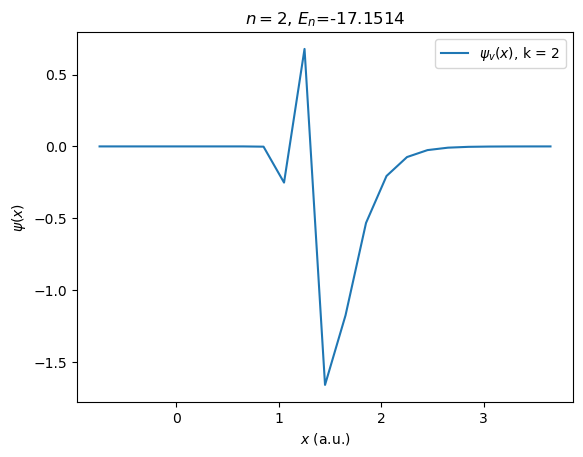

In [72]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()

# Càlcul amb modificacions (disminució de h)

Aquest cas dona un càlcul més acurat però necessita més temps per generar els gràfics 

In [73]:
# Interval for calculating the wave function [-L/2,L/2]
L = 10
xlower = -7*L/20
xupper = 7*L/20

#Discretization options
h = 0.005  #discretization in space

#Create coordinates at which the solution will be calculated
x = np.arange(xlower,xupper+h,h)
#grid size (how many discrete points to use in the range [-L/2,L/2])
npoints=len(x)

print("Using",npoints, "grid points.")

Using 1401 grid points.


In [74]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Energy Level
E = - w/(2.0*h**2)

In [75]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=-66.2726
n= 1 , E(numeric)=-66.2726
n= 2 , E(numeric)=-22.9867
n= 3 , E(numeric)=-22.9867
n= 4 , E(numeric)=-4.1353


Plotting


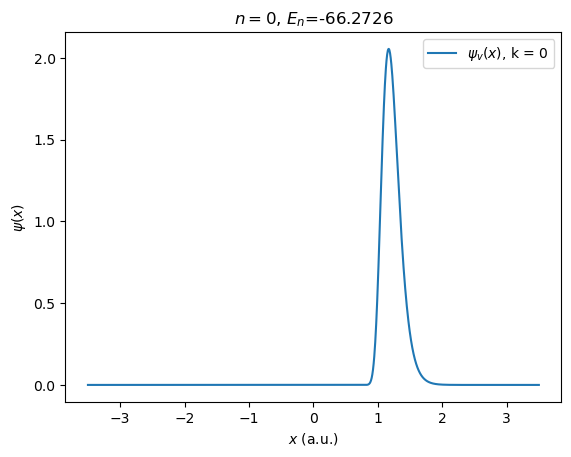

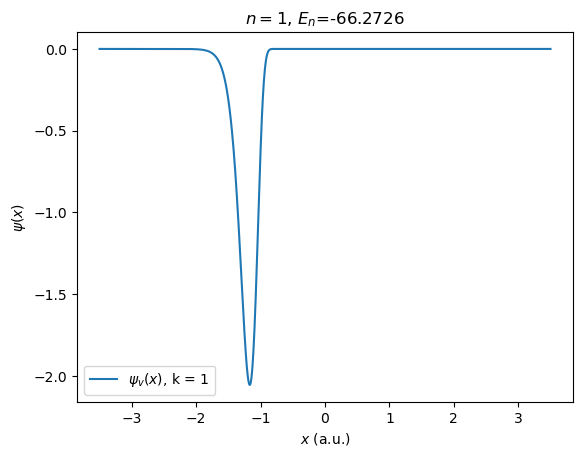

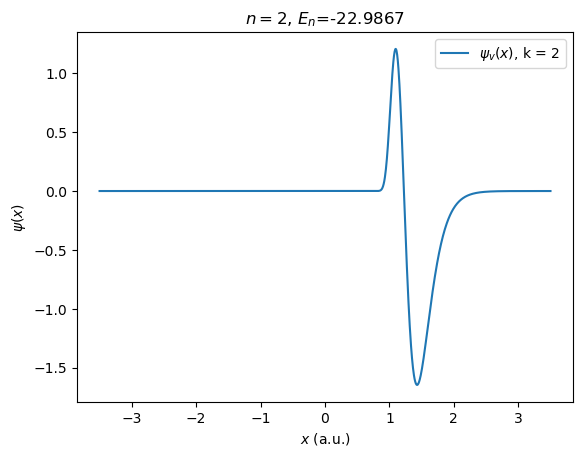

In [76]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,3):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()